# Week 4: POS Tagging & Named Entity Recognition
## Dutch Language NLP using HMM, CRF, and BiLSTM

This notebook implements:
1. **POS Tagging using Hidden Markov Models (HMM)** with Viterbi decoding
2. **POS Tagging using Conditional Random Fields (CRF)**
3. **Named Entity Recognition using HMM and CRF**
4. **POS Tagging using Neural Models (BiLSTM)**
5. **Downstream Applications** demonstration

---

In [ ]:
# Install required packages
!pip install nltk scikit-learn sklearn-crfsuite tensorflow keras gensim seaborn matplotlib pandas numpy spacy kagglehub
!python -m spacy download nl_core_news_sm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 776.0 kB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 76.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 99.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 74.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 137.4 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 143.7 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/225.0 kB 21.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 85.8 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('nl_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the pa

In [ ]:
# Import all required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict, Counter
import warnings
warnings.filterwarnings('ignore')

# For downloading Dutch corpus
import nltk
nltk.download('universal_tagset')
nltk.download('averaged_perceptron_tagger')

# For CRF
import sklearn_crfsuite
from sklearn_crfsuite import metrics as crf_metrics

# For Neural Models
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import LSTM, Embedding, Dense, TimeDistributed, Bidirectional, Input, Dropout
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

# For evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report

print("All libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")

[nltk_data] Downloading package universal_tagset to /root/nltk_data...
[nltk_data]   Unzipping taggers/universal_tagset.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


All libraries imported successfully!
TensorFlow version: 2.20.0


---
# Part 1: Dataset Preparation (Dutch Language)

We'll use the **Dutch News Articles dataset** from the workspace and apply POS tagging using spaCy's Dutch model.
The dataset will be used for both POS tagging and NER tasks.

In [3]:
# Download Dutch News Articles dataset from Kaggle
import kagglehub

# Download latest version
path = kagglehub.dataset_download("maxscheijen/dutch-news-articles")
print(f"Dataset downloaded to: {path}")

100%|██████████| 161M/161M [00:00<00:00, 172MB/s]  

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/maxscheijen/dutch-news-articles/versions/157


In [4]:
# Load Dutch News Articles dataset
import os
import spacy
import pandas as pd

# Load spaCy Dutch model
nlp = spacy.load('nl_core_news_sm')

# Load the Dutch news dataset from Kaggle
csv_path = os.path.join(path, "dutch-news-articles.csv")
print(f"Loading dataset from: {csv_path}")
df = pd.read_csv(csv_path)

print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nCategories: {df['category'].value_counts().to_dict()}")
display(df.head())

Loading dataset from: /root/.cache/kagglehub/datasets/maxscheijen/dutch-news-articles/versions/157/dutch-news-articles.csv
Dataset shape: (255524, 5)
Columns: ['datetime', 'title', 'content', 'category', 'url']

Categories: {'Buitenland': 97734, 'Binnenland': 85758, 'Politiek': 22805, 'Economie': 20818, 'Regionaal nieuws': 16657, 'Koningshuis': 3094, 'Opmerkelijk': 2788, 'Cultuur & Media': 2636, 'Tech': 1064, 'Omroep Brabant': 220, 'Nh Nieuws': 211, 'Cultuur-En-Media': 139, 'Omroep West': 130, 'Rijnmond': 125, 'Omroep Gelderland': 115, 'Regionaal Nieuws': 97, 'Rtv Noord': 94, 'Rtv Oost': 89, 'L1Mburg': 89, 'Rtv Utrecht': 85, 'Omroep Zeeland': 76, 'Omrop Fryslân': 72, 'Regio': 68, 'Omroep Flevoland': 62, 'Aardbevingen': 56, 'Rtv Drenthe': 48, 'Verkiezingen': 44, 'Strijd In Sudan': 42, 'Op Weg Naar Tk2023': 35, 'Klimaat': 31, 'Einde Rutte Iv': 25, 'Slavernijverleden': 24, 'Stikstofcrisis': 20, 'Gronings Gas': 20, '1 Jaar Oorlog': 18, 'Kroning Charles': 16, 'Turkije Kiest': 16, 'Opstand W

,datetime,title,content,category,url
0,2010-01-01 00:49:00,Enige Litouwse kerncentrale dicht,De enige kerncentrale van Litouwen is oudjaars...,Buitenland,https://nos.nl/artikel/126231-enige-litouwse-k...
1,2010-01-01 02:08:00,Spanje eerste EU-voorzitter onder nieuw verdrag,Spanje is met ingang van vandaag voorzitter va...,Buitenland,https://nos.nl/artikel/126230-spanje-eerste-eu...
2,2010-01-01 02:09:00,Fout justitie in Blackwater-zaak,Vijf werknemers van het omstreden Amerikaanse ...,Buitenland,https://nos.nl/artikel/126233-fout-justitie-in...
3,2010-01-01 05:14:00,"Museumplein vol, minder druk in Rotterdam",Het Oud en Nieuwfeest op het Museumplein in Am...,Binnenland,https://nos.nl/artikel/126232-museumplein-vol-...
4,2010-01-01 05:30:00,Obama krijgt rapporten over aanslag,President Obama heeft de eerste rapporten gekr...,Buitenland,https://nos.nl/artikel/126236-obama-krijgt-rap...


In [ ]:
# Process articles with spaCy to get POS tags and NER
def process_text_with_spacy(text, nlp, max_length=5000):
    """Process text with spaCy and extract sentences with POS and NER tags"""
    sentences = []
    pos_tags = []
    ner_tags = []
    
    # Truncate very long texts
    text = text[:max_length] if len(text) > max_length else text
    
    doc = nlp(text)
    
    for sent in doc.sents:
        sent_words = []
        sent_pos = []
        sent_ner = []
        
        for token in sent:
            if not token.is_space:
                sent_words.append(token.text)
                sent_pos.append(token.pos_)  # Universal POS tag
                # BIO format for NER
                if token.ent_iob_ == 'O':
                    sent_ner.append('O')
                else:
                    sent_ner.append(f"{token.ent_iob_}-{token.ent_type_}")
        
        if len(sent_words) > 2:  # Only keep sentences with more than 2 words
            sentences.append(sent_words)
            pos_tags.append(sent_pos)
            ner_tags.append(sent_ner)
    
    return sentences, pos_tags, ner_tags

# Process all articles
print("Processing Dutch news articles with spaCy...")
all_sentences = []
all_pos_tags = []
all_ner_tags = []

# Process each article (limit to first 250000 for speed)
for idx, row in df.head(250000).iterrows():
    content = str(row['content'])
    if len(content) > 50:  # Skip very short content
        sents, pos, ner = process_text_with_spacy(content, nlp)
        all_sentences.extend(sents)
        all_pos_tags.extend(pos)
        all_ner_tags.extend(ner)
    
    if (idx + 1) % 100 == 0:
        print(f"Processed {idx + 1} articles...")

print(f"\nTotal sentences extracted: {len(all_sentences)}")
print(f"\nSample sentence: {all_sentences[0]}")
print(f"POS tags: {all_pos_tags[0]}")
print(f"NER tags: {all_ner_tags[0]}")

Processing Dutch news articles with spaCy...
Processed 100 articles...
Processed 200 articles...
Processed 300 articles...
Processed 400 articles...
Processed 500 articles...
Processed 600 articles...
Processed 700 articles...
Processed 800 articles...
Processed 900 articles...
Processed 1000 articles...
Processed 1100 articles...
Processed 1200 articles...
Processed 1300 articles...
Processed 1400 articles...
Processed 1500 articles...
Processed 1600 articles...
Processed 1700 articles...
Processed 1800 articles...
Processed 1900 articles...
Processed 2000 articles...
Processed 2100 articles...
Processed 2200 articles...
Processed 2300 articles...
Processed 2400 articles...
Processed 2500 articles...
Processed 2600 articles...
Processed 2700 articles...
Processed 2800 articles...
Processed 2900 articles...
Processed 3000 articles...
Processed 3100 articles...
Processed 3200 articles...
Processed 3300 articles...
Processed 3400 articles...
Processed 3500 articles...
Processed 3600 arti

Training sentences: 100333
Test sentences: 25084

Universal POS Tag Distribution (Dutch News)
NOUN         : 357523 (18.28%)
ADP          : 266046 (13.60%)
DET          : 244168 (12.48%)
VERB         : 204559 (10.46%)
PUNCT        : 199268 (10.19%)
PROPN        : 137318 (7.02%)
ADJ          : 123779 (6.33%)
ADV          : 110998 (5.67%)
AUX          :  95735 (4.89%)
PRON         :  92955 (4.75%)
CCONJ        :  42034 (2.15%)
NUM          :  39691 (2.03%)
SCONJ        :  37445 (1.91%)
SYM          :   4178 (0.21%)
X            :    329 (0.02%)
INTJ         :    234 (0.01%)
SPACE        :      2 (0.00%)


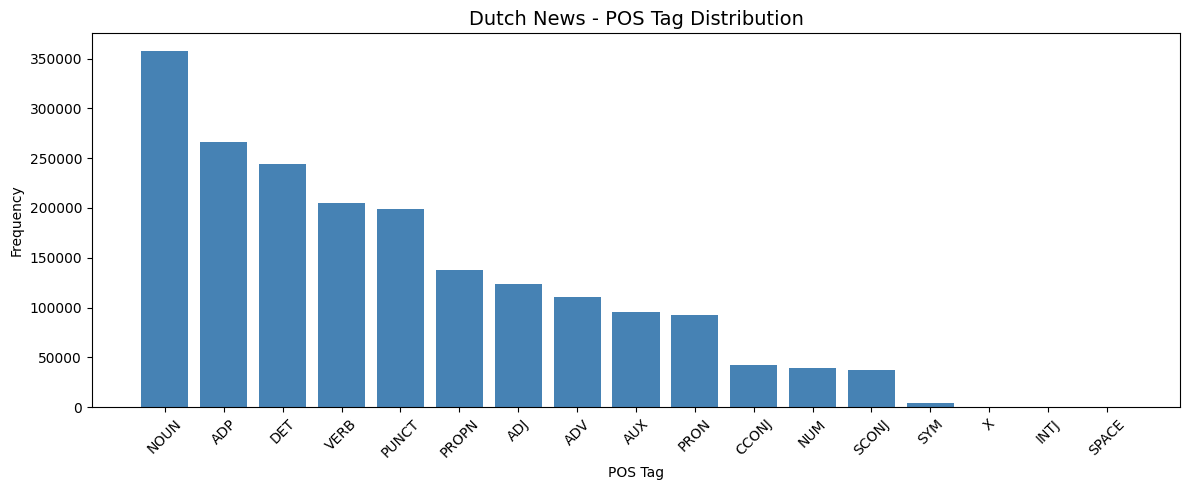

In [6]:
# Split into training and test sets
from sklearn.model_selection import train_test_split

# Create indices and split
indices = list(range(len(all_sentences)))
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42)

train_sentences = [all_sentences[i] for i in train_idx]
train_pos = [all_pos_tags[i] for i in train_idx]
train_ner = [all_ner_tags[i] for i in train_idx]

test_sentences = [all_sentences[i] for i in test_idx]
test_pos = [all_pos_tags[i] for i in test_idx]
test_ner = [all_ner_tags[i] for i in test_idx]

print(f"Training sentences: {len(train_sentences)}")
print(f"Test sentences: {len(test_sentences)}")

# Analyze POS tag distribution
all_pos_flat = [tag for tags in all_pos_tags for tag in tags]
pos_distribution = Counter(all_pos_flat)

print("\n" + "="*60)
print("Universal POS Tag Distribution (Dutch News)")
print("="*60)
for tag, count in pos_distribution.most_common():
    print(f"{tag:12} : {count:6} ({100*count/len(all_pos_flat):.2f}%)")

# Visualize
plt.figure(figsize=(12, 5))
tags, counts = zip(*pos_distribution.most_common())
plt.bar(tags, counts, color='steelblue')
plt.title('Dutch News - POS Tag Distribution', fontsize=14)
plt.xlabel('POS Tag')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
# Part 2: POS Tagging using Hidden Markov Models (HMM)

## Theory
HMM is a generative probabilistic model where:
- **States** = POS tags
- **Observations** = Words
- **Transition probabilities**: P(tag_i | tag_{i-1})
- **Emission probabilities**: P(word | tag)

The goal is to find the most likely sequence of tags given a sequence of words using the **Viterbi Algorithm**.

In [7]:
class HMMPOSTagger:
    """
    Hidden Markov Model for POS Tagging
    with Laplace smoothing for unseen words
    """
    
    def __init__(self, smoothing=1.0):
        self.smoothing = smoothing
        self.tags = set()
        self.vocab = set()
        self.transition_probs = {}  # P(tag_i | tag_{i-1})
        self.emission_probs = {}    # P(word | tag)
        self.initial_probs = {}     # P(tag | START)
        
    def train(self, sentences, tags_list):
        """Estimate transition and emission probabilities"""
        # Count frequencies
        tag_counts = defaultdict(int)
        transition_counts = defaultdict(lambda: defaultdict(int))
        emission_counts = defaultdict(lambda: defaultdict(int))
        initial_counts = defaultdict(int)
        
        for sentence, tags in zip(sentences, tags_list):
            # Add to vocabulary and tag set
            for word, tag in zip(sentence, tags):
                self.vocab.add(word.lower())
                self.tags.add(tag)
                tag_counts[tag] += 1
                emission_counts[tag][word.lower()] += 1
            
            # Initial tag
            initial_counts[tags[0]] += 1
            
            # Transition counts
            for i in range(1, len(tags)):
                transition_counts[tags[i-1]][tags[i]] += 1
        
        # Convert to probabilities with smoothing
        num_tags = len(self.tags)
        vocab_size = len(self.vocab)
        total_sentences = len(sentences)
        
        # Initial probabilities
        for tag in self.tags:
            self.initial_probs[tag] = (initial_counts[tag] + self.smoothing) / \
                                       (total_sentences + self.smoothing * num_tags)
        
        # Transition probabilities
        for prev_tag in self.tags:
            self.transition_probs[prev_tag] = {}
            total = sum(transition_counts[prev_tag].values())
            for curr_tag in self.tags:
                count = transition_counts[prev_tag][curr_tag]
                self.transition_probs[prev_tag][curr_tag] = \
                    (count + self.smoothing) / (total + self.smoothing * num_tags)
        
        # Emission probabilities
        for tag in self.tags:
            self.emission_probs[tag] = {}
            total = tag_counts[tag]
            for word in self.vocab:
                count = emission_counts[tag][word]
                self.emission_probs[tag][word] = \
                    (count + self.smoothing) / (total + self.smoothing * vocab_size)
            # For unknown words
            self.emission_probs[tag]['<UNK>'] = self.smoothing / (total + self.smoothing * vocab_size)
        
        print(f"Training complete!")
        print(f"Vocabulary size: {len(self.vocab)}")
        print(f"Number of tags: {len(self.tags)}")
        
    def get_emission_prob(self, word, tag):
        """Get emission probability with unknown word handling"""
        word = word.lower()
        if word in self.emission_probs[tag]:
            return self.emission_probs[tag][word]
        return self.emission_probs[tag]['<UNK>']
    
    def viterbi(self, sentence, return_matrix=False):
        """
        Viterbi Algorithm for decoding
        Returns the most likely tag sequence
        """
        n = len(sentence)
        tags_list = list(self.tags)
        num_tags = len(tags_list)
        
        # Viterbi matrix (log probabilities for numerical stability)
        viterbi_matrix = np.full((num_tags, n), -np.inf)
        backpointer = np.zeros((num_tags, n), dtype=int)
        
        # Initialization (t=0)
        for i, tag in enumerate(tags_list):
            viterbi_matrix[i, 0] = np.log(self.initial_probs[tag]) + \
                                   np.log(self.get_emission_prob(sentence[0], tag))
        
        # Recursion
        for t in range(1, n):
            for j, curr_tag in enumerate(tags_list):
                for i, prev_tag in enumerate(tags_list):
                    score = viterbi_matrix[i, t-1] + \
                            np.log(self.transition_probs[prev_tag][curr_tag]) + \
                            np.log(self.get_emission_prob(sentence[t], curr_tag))
                    if score > viterbi_matrix[j, t]:
                        viterbi_matrix[j, t] = score
                        backpointer[j, t] = i
        
        # Termination - find best final state
        best_final_idx = np.argmax(viterbi_matrix[:, -1])
        
        # Backtrack
        best_path = [best_final_idx]
        for t in range(n-1, 0, -1):
            best_path.insert(0, backpointer[best_path[0], t])
        
        # Convert indices to tags
        predicted_tags = [tags_list[idx] for idx in best_path]
        
        if return_matrix:
            return predicted_tags, viterbi_matrix, tags_list
        return predicted_tags
    
    def predict(self, sentences):
        """Predict tags for multiple sentences"""
        return [self.viterbi(sent) for sent in sentences]

# Train the HMM model
hmm_tagger = HMMPOSTagger(smoothing=1.0)
hmm_tagger.train(train_sentences, train_pos)

Training complete!
Vocabulary size: 63726
Number of tags: 17


## Transition and Emission Probability Tables

TRANSITION PROBABILITY TABLE P(tag_i | tag_{i-1})
Rows = Previous Tag, Columns = Current Tag



,ADJ,ADP,ADV,AUX,CCONJ,DET,INTJ,NOUN,NUM,PRON,PROPN,PUNCT,SCONJ,SPACE,SYM,VERB,X
ADJ,0.0536,0.0933,0.0235,0.0550,0.0177,0.0206,0.0001,0.5050,0.0185,0.0072,0.0258,0.0737,0.0220,0.0000,0.0016,0.0824,0.0001
ADP,0.0430,0.0360,0.0130,0.0079,0.0033,0.4323,0.0000,0.1324,0.0522,0.0505,0.1272,0.0201,0.0054,0.0000,0.0029,0.0735,0.0003
ADV,0.1214,0.1660,0.1368,0.0833,0.0047,0.1234,0.0001,0.0535,0.0386,0.0359,0.0119,0.0367,0.0228,0.0000,0.0006,0.1640,0.0001
AUX,0.0602,0.1246,0.1350,0.0343,0.0061,0.1457,0.0000,0.0332,0.0173,0.0768,0.0185,0.0655,0.0162,0.0000,0.0003,0.2661,0.0001
CCONJ,0.0747,0.0711,0.0917,0.0402,0.0008,0.1675,0.0004,0.1796,0.0282,0.0871,0.1152,0.0061,0.0243,0.0000,0.0035,0.1093,0.0004
DET,0.1824,0.0021,0.0067,0.0001,0.0001,0.0029,0.0000,0.6654,0.0145,0.0028,0.0831,0.0043,0.0000,0.0000,0.0022,0.0331,0.0002
INTJ,0.0048,0.0481,0.0240,0.0192,0.0481,0.0096,0.0288,0.0337,0.0048,0.0144,0.0240,0.6635,0.0048,0.0048,0.0192,0.0433,0.0048
NOUN,0.0318,0.3094,0.0449,0.0965,0.0379,0.0240,0.0000,0.0332,0.0077,0.0265,0.0459,0.1669,0.0128,0.0000,0.0009,0.1614,0.0001
NUM,0.0614,0.0811,0.0107,0.0314,0.0199,0.0121,0.0000,0.5724,0.0052,0.0054,0.0602,0.0751,0.0044,0.0000,0.0042,0.0560,0.0003
PRON,0.0813,0.1319,0.1222,0.1275,0.0032,0.0724,0.0001,0.1557,0.0100,0.0530,0.0112,0.0196,0.0215,0.0000,0.0007,0.1896,0.0001


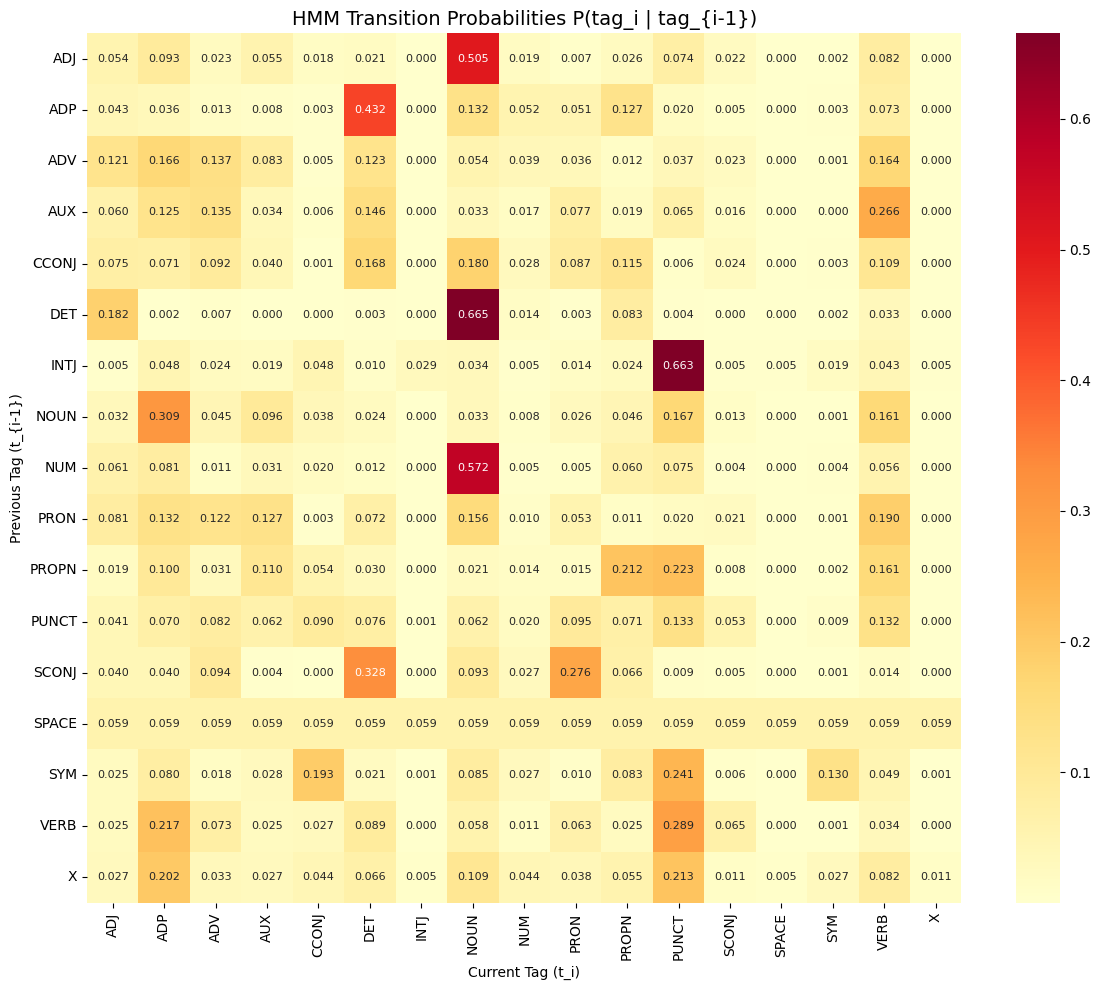

In [8]:
# Create Transition Probability Table
tags_sorted = sorted(hmm_tagger.tags)
transition_df = pd.DataFrame(index=tags_sorted, columns=tags_sorted)

for prev_tag in tags_sorted:
    for curr_tag in tags_sorted:
        transition_df.loc[prev_tag, curr_tag] = f"{hmm_tagger.transition_probs[prev_tag][curr_tag]:.4f}"

print("=" * 60)
print("TRANSITION PROBABILITY TABLE P(tag_i | tag_{i-1})")
print("=" * 60)
print("Rows = Previous Tag, Columns = Current Tag")
print()
display(transition_df)

# Visualize transition probabilities as heatmap
transition_matrix = np.array([[float(hmm_tagger.transition_probs[p][c]) 
                               for c in tags_sorted] for p in tags_sorted])

plt.figure(figsize=(12, 10))
sns.heatmap(transition_matrix, xticklabels=tags_sorted, yticklabels=tags_sorted, 
            annot=True, fmt='.3f', cmap='YlOrRd', annot_kws={'size': 8})
plt.title('HMM Transition Probabilities P(tag_i | tag_{i-1})', fontsize=14)
plt.xlabel('Current Tag (t_i)')
plt.ylabel('Previous Tag (t_{i-1})')
plt.tight_layout()
plt.show()

In [9]:
# Show top emission probabilities for each tag
print("=" * 60)
print("TOP EMISSION PROBABILITIES P(word | tag)")
print("=" * 60)

emission_data = []
for tag in tags_sorted:
    # Get top 5 words for each tag
    word_probs = [(word, prob) for word, prob in hmm_tagger.emission_probs[tag].items() 
                  if word != '<UNK>']
    word_probs.sort(key=lambda x: x[1], reverse=True)
    top_words = word_probs[:5]
    
    for word, prob in top_words:
        emission_data.append({'Tag': tag, 'Word': word, 'P(word|tag)': f"{prob:.6f}"})

emission_df = pd.DataFrame(emission_data)
print("\nTop 5 words with highest emission probability for each POS tag:")
display(emission_df.pivot_table(index='Tag', values=['Word', 'P(word|tag)'], 
                                 aggfunc=lambda x: list(x)[:5]).head(20))

TOP EMISSION PROBABILITIES P(word | tag)

Top 5 words with highest emission probability for each POS tag:


,P(word|tag),Word
Tag,,
ADJ,"[0.011488, 0.011328, 0.008968, 0.008710, 0.008...","[andere, nieuwe, grote, eerste, nederlandse]"
ADP,"[0.157693, 0.131060, 0.062588, 0.049904, 0.045...","[van, in, op, te, voor]"
ADV,"[0.062210, 0.060563, 0.045899, 0.032706, 0.022...","[niet, er, ook, nog, al]"
AUX,"[0.129214, 0.057924, 0.043214, 0.038737, 0.033...","[is, zijn, heeft, was, worden]"
CCONJ,"[0.261630, 0.054787, 0.020768, 0.004437, 0.001...","[en, maar, of, want, zowel]"
DET,"[0.405761, 0.143418, 0.131465, 0.011621, 0.008...","[de, het, een, geen, die]"
INTJ,"[0.001345, 0.000970, 0.000250, 0.000125, 0.000...","[ja, nee, hoor, ach, jazeker]"
NOUN,"[0.014629, 0.009872, 0.005329, 0.005186, 0.005...","[jaar, mensen, euro, politie, procent]"
NUM,"[0.029682, 0.015899, 0.009311, 0.008222, 0.007...","[twee, drie, vier, vijf, tien]"


## Viterbi Algorithm - Step-by-Step Visualization

Sample Dutch Sentence:
Words: ['Het', 'VN-kinderfonds', 'Unicef', 'is', 'erg', 'bezorgd', 'en', 'zegt']
True POS: ['DET', 'NOUN', 'PROPN', 'AUX', 'ADJ', 'VERB', 'CCONJ', 'VERB']

Predicted POS: ['DET', 'NOUN', 'PROPN', 'AUX', 'ADJ', 'VERB', 'CCONJ', 'VERB']

VITERBI MATRIX (Log Probabilities)

Viterbi Matrix (showing log probabilities at each step):


,Het,VN-kinderfonds,Unicef,is,erg,bezorgd,en,zegt
ADV,-14.13,-19.02,-30.35,-42.37,-45.15,-56.02,-65.91,-70.64
ADJ,-15.21,-16.94,-30.76,-42.93,-40.33,-53.87,-67.06,-70.91
NOUN,-15.44,-15.31,-30.39,-43.60,-47.38,-53.78,-66.97,-70.79
VERB,-16.86,-18.98,-29.47,-34.38,-44.87,-51.36,-67.09,-62.95
SYM,-17.68,-20.45,-33.43,-44.16,-50.32,-57.91,-68.66,-73.09
DET,-3.24,-20.08,-31.51,-42.32,-45.60,-56.68,-66.24,-70.56
AUX,-17.91,-18.90,-29.50,-31.21,-46.44,-55.09,-66.92,-71.38
ADP,-14.35,-19.54,-29.02,-41.80,-45.83,-55.24,-65.42,-71.49
INTJ,-18.89,-24.40,-36.63,-47.13,-52.43,-60.50,-72.97,-75.09
X,-19.64,-22.72,-35.44,-47.55,-51.74,-61.11,-71.43,-75.32


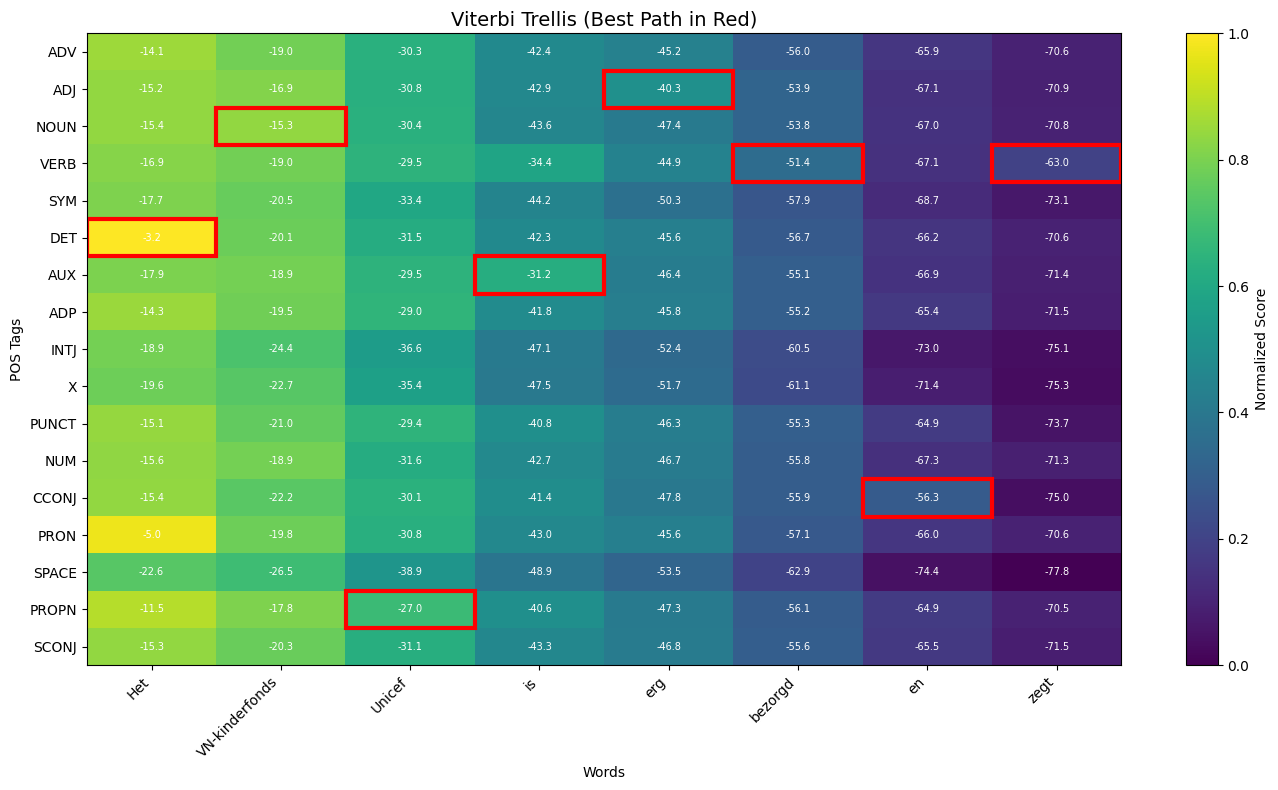


✓ Red boxes indicate the optimal path found by Viterbi algorithm


In [10]:
# Demonstrate Viterbi on a sample sentence
sample_idx = 5
sample_sentence = train_sentences[sample_idx][:8]  # Take first 8 words for visualization
true_tags = train_pos[sample_idx][:8]

print("Sample Dutch Sentence:")
print(f"Words: {sample_sentence}")
print(f"True POS: {true_tags}")
print()

# Run Viterbi with matrix output
predicted_tags, viterbi_matrix, tags_order = hmm_tagger.viterbi(sample_sentence, return_matrix=True)

print(f"Predicted POS: {predicted_tags}")
print()

# Create Viterbi matrix visualization
print("=" * 80)
print("VITERBI MATRIX (Log Probabilities)")
print("=" * 80)

# Convert to DataFrame for better display
viterbi_df = pd.DataFrame(
    viterbi_matrix,
    index=tags_order,
    columns=sample_sentence
)

# Display the matrix
print("\nViterbi Matrix (showing log probabilities at each step):")
display(viterbi_df.round(2))

# Visualize the Viterbi trellis
fig, ax = plt.subplots(figsize=(14, 8))

# Normalize for visualization (convert from log space)
viterbi_normalized = viterbi_matrix - viterbi_matrix.min()
viterbi_normalized = viterbi_normalized / viterbi_normalized.max()

im = ax.imshow(viterbi_normalized, aspect='auto', cmap='viridis')

# Add labels
ax.set_xticks(range(len(sample_sentence)))
ax.set_xticklabels(sample_sentence, rotation=45, ha='right')
ax.set_yticks(range(len(tags_order)))
ax.set_yticklabels(tags_order)

# Add text annotations
for i in range(len(tags_order)):
    for j in range(len(sample_sentence)):
        text = ax.text(j, i, f'{viterbi_matrix[i, j]:.1f}',
                       ha="center", va="center", color="w", fontsize=7)

# Highlight the best path
for t, tag in enumerate(predicted_tags):
    tag_idx = tags_order.index(tag)
    rect = plt.Rectangle((t-0.5, tag_idx-0.5), 1, 1, fill=False, 
                          edgecolor='red', linewidth=3)
    ax.add_patch(rect)

plt.colorbar(im, label='Normalized Score')
ax.set_xlabel('Words')
ax.set_ylabel('POS Tags')
ax.set_title('Viterbi Trellis (Best Path in Red)', fontsize=14)
plt.tight_layout()
plt.show()

print("\n✓ Red boxes indicate the optimal path found by Viterbi algorithm")

## HMM Evaluation

In [11]:
# Evaluate HMM on test set
print("Evaluating HMM POS Tagger on test set...")
hmm_predictions = hmm_tagger.predict(test_sentences)

# Flatten for evaluation
y_true_hmm = [tag for tags in test_pos for tag in tags]
y_pred_hmm = [tag for tags in hmm_predictions for tag in tags]

# Calculate accuracy
hmm_accuracy = accuracy_score(y_true_hmm, y_pred_hmm)
print(f"\n{'='*60}")
print(f"HMM POS TAGGING RESULTS")
print(f"{'='*60}")
print(f"Overall Accuracy: {hmm_accuracy:.4f} ({hmm_accuracy*100:.2f}%)")

# Per-tag performance
print(f"\nPer-Tag Performance:")
print(classification_report(y_true_hmm, y_pred_hmm, zero_division=0))

Evaluating HMM POS Tagger on test set...

HMM POS TAGGING RESULTS
Overall Accuracy: 0.9343 (93.43%)

Per-Tag Performance:
              precision    recall  f1-score   support

         ADJ       0.92      0.90      0.91     24812
         ADP       0.96      1.00      0.98     52898
         ADV       0.93      0.96      0.94     22304
         AUX       0.88      0.96      0.92     18950
       CCONJ       0.97      0.98      0.98      8401
         DET       0.95      0.98      0.96     49057
        INTJ       1.00      0.48      0.65        42
        NOUN       0.93      0.93      0.93     71458
         NUM       1.00      0.90      0.95      7937
        PRON       0.90      0.90      0.90     18611
       PROPN       0.88      0.78      0.83     27194
       PUNCT       0.98      1.00      0.99     39849
       SCONJ       0.89      0.90      0.89      7469
       SPACE       0.00      0.00      0.00         1
         SYM       0.78      0.12      0.20       830
        VERB 

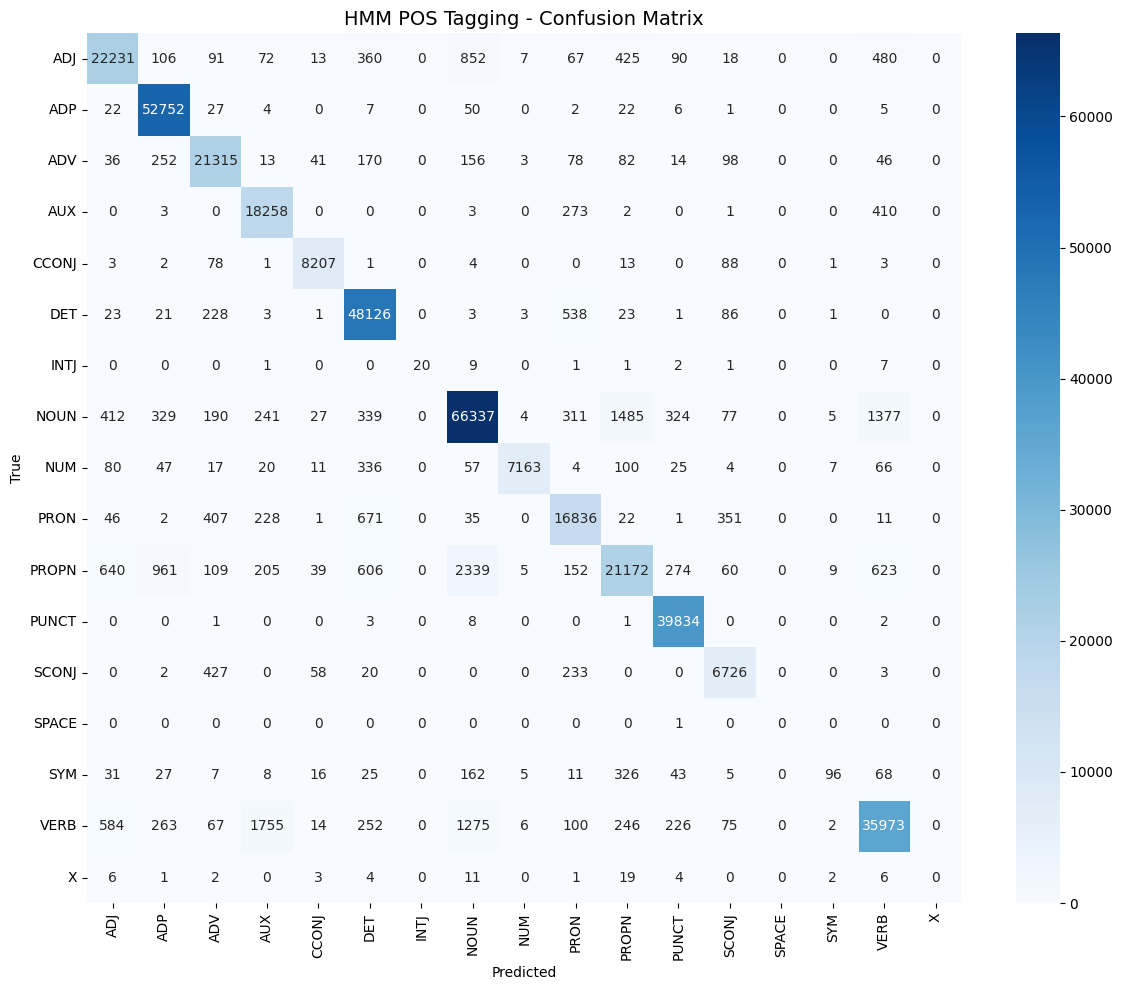


ERROR ANALYSIS - Most Common Mistakes

Top 10 most common tagging errors (True → Predicted):
  PROPN    → NOUN     :  2339 times
  VERB     → AUX      :  1755 times
  NOUN     → PROPN    :  1485 times
  NOUN     → VERB     :  1377 times
  VERB     → NOUN     :  1275 times
  PROPN    → ADP      :   961 times
  ADJ      → NOUN     :   852 times
  PRON     → DET      :   671 times
  PROPN    → ADJ      :   640 times
  PROPN    → VERB     :   623 times


In [12]:
# Confusion matrix for HMM
tags_in_data = sorted(list(set(y_true_hmm) | set(y_pred_hmm)))
cm_hmm = confusion_matrix(y_true_hmm, y_pred_hmm, labels=tags_in_data)

plt.figure(figsize=(12, 10))
sns.heatmap(cm_hmm, xticklabels=tags_in_data, yticklabels=tags_in_data, 
            annot=True, fmt='d', cmap='Blues')
plt.title('HMM POS Tagging - Confusion Matrix', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

# Error Analysis
print("\n" + "="*60)
print("ERROR ANALYSIS - Most Common Mistakes")
print("="*60)

errors = [(true, pred) for true, pred in zip(y_true_hmm, y_pred_hmm) if true != pred]
error_counts = Counter(errors)

print("\nTop 10 most common tagging errors (True → Predicted):")
for (true_tag, pred_tag), count in error_counts.most_common(10):
    print(f"  {true_tag:8} → {pred_tag:8} : {count:5} times")

---
# Part 3: POS Tagging using Conditional Random Fields (CRF)

## Theory
CRF is a **discriminative** model that directly models P(tags|words).

Key advantages over HMM:
- Can use arbitrary features (not just current word)
- No independence assumptions
- Better handles unknown words through features

In [13]:
def extract_word_features(sentence, idx):
    """
    Extract rich features for CRF
    Features include:
    - Current word
    - Prefixes and suffixes
    - Capitalization patterns
    - Word shape
    - Context words
    """
    word = sentence[idx]
    
    features = {
        # Current word features
        'word.lower()': word.lower(),
        'word[-3:]': word[-3:],  # Suffix
        'word[-2:]': word[-2:],
        'word[:3]': word[:3],    # Prefix
        'word[:2]': word[:2],
        
        # Capitalization features
        'word.isupper()': word.isupper(),
        'word.istitle()': word.istitle(),
        'word.isdigit()': word.isdigit(),
        'word.isalpha()': word.isalpha(),
        
        # Word shape features
        'word.length': len(word),
        'word.has_hyphen': '-' in word,
        'word.has_digit': any(c.isdigit() for c in word),
        
        # Word shape (X for upper, x for lower, d for digit)
        'word.shape': ''.join(
            'X' if c.isupper() else 'x' if c.islower() else 'd' if c.isdigit() else c 
            for c in word
        )[:5],  # First 5 characters of shape
        
        # Position features
        'BOS': idx == 0,  # Beginning of sentence
        'EOS': idx == len(sentence) - 1,  # End of sentence
    }
    
    # Previous word features
    if idx > 0:
        prev_word = sentence[idx - 1]
        features.update({
            '-1:word.lower()': prev_word.lower(),
            '-1:word.istitle()': prev_word.istitle(),
            '-1:word.isupper()': prev_word.isupper(),
            '-1:word[-3:]': prev_word[-3:],
        })
    else:
        features['BOS'] = True
    
    # Next word features
    if idx < len(sentence) - 1:
        next_word = sentence[idx + 1]
        features.update({
            '+1:word.lower()': next_word.lower(),
            '+1:word.istitle()': next_word.istitle(),
            '+1:word.isupper()': next_word.isupper(),
            '+1:word[-3:]': next_word[-3:],
        })
    else:
        features['EOS'] = True
    
    # Two words back
    if idx > 1:
        features['-2:word.lower()'] = sentence[idx - 2].lower()
    
    # Two words ahead
    if idx < len(sentence) - 2:
        features['+2:word.lower()'] = sentence[idx + 2].lower()
    
    return features

def sent_to_features(sentence):
    """Convert sentence to feature list"""
    return [extract_word_features(sentence, i) for i in range(len(sentence))]

def sent_to_labels(tags):
    """Convert tags to label list"""
    return tags

# Show example features
print("=" * 60)
print("CRF FEATURE ENGINEERING")
print("=" * 60)
print("\nSample sentence:", train_sentences[0][:5])
print("\nFeatures for word '{}':\n".format(train_sentences[0][2]))
for key, value in extract_word_features(train_sentences[0], 2).items():
    print(f"  {key:25}: {value}")

CRF FEATURE ENGINEERING

Sample sentence: ['Van', 'al', 'deze', 'modellen', 'rijden']

Features for word 'deze':

  word.lower()             : deze
  word[-3:]                : eze
  word[-2:]                : ze
  word[:3]                 : dez
  word[:2]                 : de
  word.isupper()           : False
  word.istitle()           : False
  word.isdigit()           : False
  word.isalpha()           : True
  word.length              : 4
  word.has_hyphen          : False
  word.has_digit           : False
  word.shape               : xxxx
  BOS                      : False
  EOS                      : False
  -1:word.lower()          : al
  -1:word.istitle()        : False
  -1:word.isupper()        : False
  -1:word[-3:]             : al
  +1:word.lower()          : modellen
  +1:word.istitle()        : False
  +1:word.isupper()        : False
  +1:word[-3:]             : len
  -2:word.lower()          : van
  +2:word.lower()          : rijden


In [14]:
# Prepare CRF training data
print("Preparing features for CRF training...")
X_train_crf = [sent_to_features(s) for s in train_sentences]
y_train_crf = [sent_to_labels(t) for t in train_pos]

X_test_crf = [sent_to_features(s) for s in test_sentences]
y_test_crf = [sent_to_labels(t) for t in test_pos]

print(f"Training samples: {len(X_train_crf)}")
print(f"Test samples: {len(X_test_crf)}")

# Train CRF model
print("\nTraining CRF model...")
crf = sklearn_crfsuite.CRF(
    algorithm='lbfgs',
    c1=0.1,  # L1 regularization
    c2=0.1,  # L2 regularization
    max_iterations=100,
    all_possible_transitions=True,
    verbose=True
)

crf.fit(X_train_crf, y_train_crf)
print("\nCRF Training complete!")

Preparing features for CRF training...
Training samples: 100333
Test samples: 25084

Training CRF model...


loading training data to CRFsuite: 100%|██████████| 100333/100333 [00:24<00:00, 4170.44it/s]



Feature generation
type: CRF1d
feature.minfreq: 0.000000
feature.possible_states: 0
feature.possible_transitions: 1
0....1....2....3....4....5....6....7....8....9....10
Number of features: 768108
Seconds required: 5.604

L-BFGS optimization
c1: 0.100000
c2: 0.100000
num_memories: 6
max_iterations: 100
epsilon: 0.000010
stop: 10
delta: 0.000010
linesearch: MoreThuente
linesearch.max_iterations: 20

Iter 1   time=8.38  loss=3905445.92 active=756543 feature_norm=0.50
Iter 2   time=2.79  loss=3706345.71 active=744057 feature_norm=0.54
Iter 3   time=2.79  loss=3581344.94 active=753213 feature_norm=0.71
Iter 4   time=2.83  loss=3321268.79 active=748852 feature_norm=1.28
Iter 5   time=2.82  loss=2783034.74 active=749400 feature_norm=2.64
Iter 6   time=2.81  loss=2393461.51 active=756760 feature_norm=4.58
Iter 7   time=2.82  loss=2101647.03 active=761058 feature_norm=6.06
Iter 8   time=2.82  loss=1934033.41 active=760216 feature_norm=7.26
Iter 9   time=2.82  loss=1688871.73 active=756191 feat

In [15]:
# Analyze CRF feature weights
print("=" * 60)
print("CRF FEATURE WEIGHTS ANALYSIS")
print("=" * 60)

def get_top_features(crf, tag, n=10):
    """Get top features for a specific tag"""
    state_features = crf.state_features_
    tag_features = [(fname, weight) for (fname, t), weight in state_features.items() if t == tag]
    tag_features.sort(key=lambda x: abs(x[1]), reverse=True)
    return tag_features[:n]

# Show top features for selected POS tags
important_tags = ['NOUN', 'VERB', 'ADJ', 'ADV', 'DET']
print("\nTop 5 features with highest weights for each POS tag:\n")

for tag in important_tags:
    if tag in crf.classes_:
        features = get_top_features(crf, tag, n=5)
        print(f"{tag}:")
        for fname, weight in features:
            print(f"  {fname:35} : {weight:+.4f}")
        print()

CRF FEATURE WEIGHTS ANALYSIS

Top 5 features with highest weights for each POS tag:

NOUN:
  word.lower():geweld                 : +8.4312
  word.lower():geld                   : +8.4104
  word.lower():schande                : +8.1983
  word.lower():jaren                  : +7.4319
  word.lower():voet                   : +7.4067

VERB:
  word.lower():doen                   : +7.9081
  word.lower():ondervraagden          : +7.3613
  word.lower():liet                   : +7.2170
  word.lower():ziet                   : +7.0110
  word.lower():meedoen                : +6.9835

ADJ:
  word.lower():beleggers              : +9.7926
  word.lower():gemiddeld              : +9.7566
  word.lower():jongeren               : +9.2333
  word.lower():open                   : +9.1709
  word.lower():eigen                  : +9.0667

ADV:
  word.lower():bijvoorbeeld           : +9.7022
  word.lower():samen                  : +9.2147
  word.lower():niet                   : +8.7208
  word.lower():alleen     

In [16]:
# Evaluate CRF
print("Evaluating CRF POS Tagger on test set...")
y_pred_crf_nested = crf.predict(X_test_crf)

# Flatten predictions
y_true_crf = [tag for tags in y_test_crf for tag in tags]
y_pred_crf = [tag for tags in y_pred_crf_nested for tag in tags]

# Calculate metrics
crf_accuracy = accuracy_score(y_true_crf, y_pred_crf)
crf_precision, crf_recall, crf_f1, _ = precision_recall_fscore_support(
    y_true_crf, y_pred_crf, average='weighted', zero_division=0
)

print(f"\n{'='*60}")
print(f"CRF POS TAGGING RESULTS")
print(f"{'='*60}")
print(f"Overall Accuracy:  {crf_accuracy:.4f} ({crf_accuracy*100:.2f}%)")
print(f"Weighted Precision: {crf_precision:.4f}")
print(f"Weighted Recall:    {crf_recall:.4f}")
print(f"Weighted F1-Score:  {crf_f1:.4f}")

print(f"\nPer-Tag Performance:")
print(classification_report(y_true_crf, y_pred_crf, zero_division=0))

Evaluating CRF POS Tagger on test set...

CRF POS TAGGING RESULTS
Overall Accuracy:  0.9762 (97.62%)
Weighted Precision: 0.9762
Weighted Recall:    0.9762
Weighted F1-Score:  0.9762

Per-Tag Performance:
              precision    recall  f1-score   support

         ADJ       0.97      0.95      0.96     24812
         ADP       1.00      1.00      1.00     52898
         ADV       0.97      0.98      0.97     22304
         AUX       0.94      0.98      0.96     18950
       CCONJ       0.99      1.00      0.99      8401
         DET       0.99      0.99      0.99     49057
        INTJ       0.95      0.98      0.96        42
        NOUN       0.97      0.97      0.97     71458
         NUM       0.99      0.99      0.99      7937
        PRON       0.97      0.96      0.97     18611
       PROPN       0.95      0.96      0.95     27194
       PUNCT       1.00      1.00      1.00     39849
       SCONJ       0.96      0.97      0.96      7469
       SPACE       0.00      0.00      

---
# Part 4: Named Entity Recognition (NER)

## BIO Tagging Format
- **B-XXX**: Beginning of entity XXX
- **I-XXX**: Inside entity XXX  
- **O**: Outside any entity

We'll use the NER tags extracted from our Dutch News Articles using spaCy.

NER Training sentences: 100333
NER Test sentences: 25084

NER Tag Distribution (Dutch News Articles)
  O                   : 1743319 (89.11%)
  B-GPE               :  33519 (1.71%)
  B-PERSON            :  22736 (1.16%)
  B-ORG               :  20167 (1.03%)
  B-DATE              :  19408 (0.99%)
  B-NORP              :  16582 (0.85%)
  B-CARDINAL          :  15684 (0.80%)
  I-PERSON            :  15561 (0.80%)
  I-DATE              :  12014 (0.61%)
  I-ORG               :  10466 (0.53%)
  I-WORK_OF_ART       :  10400 (0.53%)
  B-ORDINAL           :   3169 (0.16%)
  I-GPE               :   3084 (0.16%)
  B-WORK_OF_ART       :   3040 (0.16%)
  I-MONEY             :   3022 (0.15%)


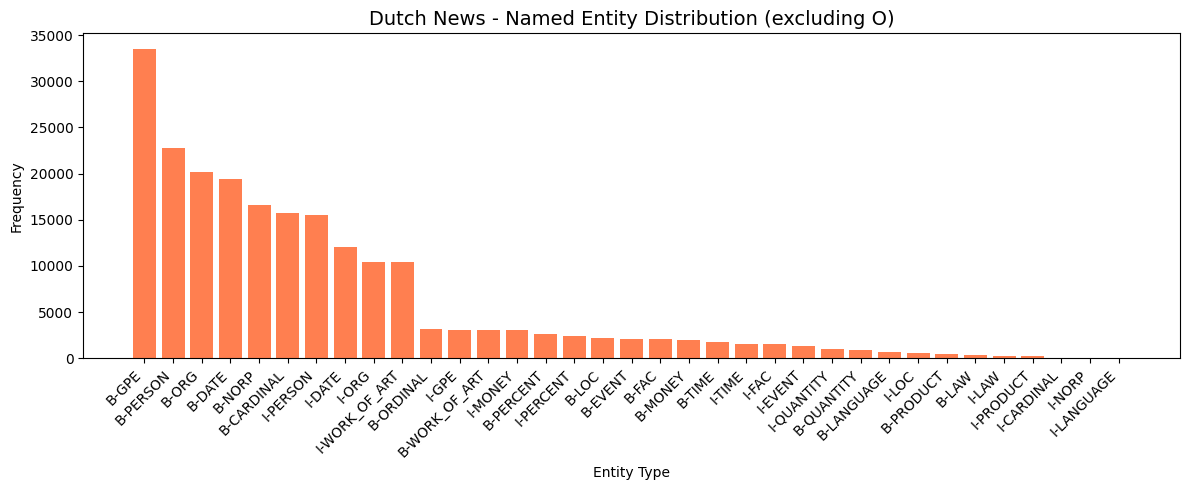

In [17]:
# Use NER data extracted from Dutch News Articles
# NER tags were already extracted using spaCy in Part 1

# Split NER data (same split as POS)
ner_train_sents = train_sentences
ner_train_tags = train_ner
ner_test_sents = test_sentences
ner_test_tags = test_ner

print(f"NER Training sentences: {len(ner_train_sents)}")
print(f"NER Test sentences: {len(ner_test_sents)}")

# Show NER tag distribution
all_ner_flat = [tag for tags in all_ner_tags for tag in tags]
ner_distribution = Counter(all_ner_flat)

print("\n" + "="*60)
print("NER Tag Distribution (Dutch News Articles)")
print("="*60)
for tag, count in ner_distribution.most_common(15):
    print(f"  {tag:20}: {count:6} ({100*count/len(all_ner_flat):.2f}%)")

# Visualize NER distribution (excluding 'O' for better visibility)
ner_no_o = {k: v for k, v in ner_distribution.items() if k != 'O'}
if ner_no_o:
    plt.figure(figsize=(12, 5))
    tags, counts = zip(*sorted(ner_no_o.items(), key=lambda x: x[1], reverse=True))
    plt.bar(tags, counts, color='coral')
    plt.title('Dutch News - Named Entity Distribution (excluding O)', fontsize=14)
    plt.xlabel('Entity Type')
    plt.ylabel('Frequency')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [18]:
# Show sample NER tagged sentence from Dutch News
print("=" * 60)
print("SAMPLE NER TAGGED SENTENCE (BIO Format)")
print("=" * 60)

# Find a sentence with named entities
sample_ner_idx = None
for i, tags in enumerate(ner_train_tags):
    if any(t != 'O' for t in tags):
        sample_ner_idx = i
        break

if sample_ner_idx:
    print(f"\nSentence: {' '.join(ner_train_sents[sample_ner_idx])}")
    print(f"\nWord-by-word tagging:")
    for word, ner in zip(ner_train_sents[sample_ner_idx], ner_train_tags[sample_ner_idx]):
        marker = "  ★" if ner != 'O' else "   "
        print(f"{marker} {word:25} | NER: {ner}")
else:
    print("No sentences with named entities found in sample.")

SAMPLE NER TAGGED SENTENCE (BIO Format)
No sentences with named entities found in sample.


## HMM-based NER

In [19]:
# HMM for NER (reuse HMM class)
class HMMNERTagger:
    """HMM for Named Entity Recognition with BIO tags"""
    
    def __init__(self, smoothing=1.0):
        self.smoothing = smoothing
        self.tags = set()
        self.vocab = set()
        self.transition_probs = {}
        self.emission_probs = {}
        self.initial_probs = {}
        
    def train(self, sentences, tags_list):
        """Estimate transition and emission probabilities for NER"""
        tag_counts = defaultdict(int)
        transition_counts = defaultdict(lambda: defaultdict(int))
        emission_counts = defaultdict(lambda: defaultdict(int))
        initial_counts = defaultdict(int)
        
        for sentence, tags in zip(sentences, tags_list):
            for word, tag in zip(sentence, tags):
                self.vocab.add(word.lower())
                self.tags.add(tag)
                tag_counts[tag] += 1
                emission_counts[tag][word.lower()] += 1
            
            initial_counts[tags[0]] += 1
            
            for i in range(1, len(tags)):
                transition_counts[tags[i-1]][tags[i]] += 1
        
        num_tags = len(self.tags)
        vocab_size = len(self.vocab)
        total_sentences = len(sentences)
        
        # Initial probabilities
        for tag in self.tags:
            self.initial_probs[tag] = (initial_counts[tag] + self.smoothing) / \
                                       (total_sentences + self.smoothing * num_tags)
        
        # Transition probabilities
        for prev_tag in self.tags:
            self.transition_probs[prev_tag] = {}
            total = sum(transition_counts[prev_tag].values())
            for curr_tag in self.tags:
                count = transition_counts[prev_tag][curr_tag]
                self.transition_probs[prev_tag][curr_tag] = \
                    (count + self.smoothing) / (total + self.smoothing * num_tags)
        
        # Emission probabilities
        for tag in self.tags:
            self.emission_probs[tag] = {}
            total = tag_counts[tag]
            for word in self.vocab:
                count = emission_counts[tag][word]
                self.emission_probs[tag][word] = \
                    (count + self.smoothing) / (total + self.smoothing * vocab_size)
            self.emission_probs[tag]['<UNK>'] = self.smoothing / (total + self.smoothing * vocab_size)
        
        print(f"HMM NER Training complete!")
        print(f"Vocabulary size: {len(self.vocab)}")
        print(f"Number of NER tags: {len(self.tags)}")
        
    def get_emission_prob(self, word, tag):
        word = word.lower()
        if word in self.emission_probs[tag]:
            return self.emission_probs[tag][word]
        return self.emission_probs[tag]['<UNK>']
    
    def viterbi(self, sentence):
        n = len(sentence)
        tags_list = list(self.tags)
        num_tags = len(tags_list)
        
        viterbi_matrix = np.full((num_tags, n), -np.inf)
        backpointer = np.zeros((num_tags, n), dtype=int)
        
        for i, tag in enumerate(tags_list):
            viterbi_matrix[i, 0] = np.log(self.initial_probs[tag]) + \
                                   np.log(self.get_emission_prob(sentence[0], tag))
        
        for t in range(1, n):
            for j, curr_tag in enumerate(tags_list):
                for i, prev_tag in enumerate(tags_list):
                    score = viterbi_matrix[i, t-1] + \
                            np.log(self.transition_probs[prev_tag][curr_tag]) + \
                            np.log(self.get_emission_prob(sentence[t], curr_tag))
                    if score > viterbi_matrix[j, t]:
                        viterbi_matrix[j, t] = score
                        backpointer[j, t] = i
        
        best_final_idx = np.argmax(viterbi_matrix[:, -1])
        
        best_path = [best_final_idx]
        for t in range(n-1, 0, -1):
            best_path.insert(0, backpointer[best_path[0], t])
        
        return [tags_list[idx] for idx in best_path]
    
    def predict(self, sentences):
        return [self.viterbi(sent) for sent in sentences]

# Train HMM NER
hmm_ner = HMMNERTagger(smoothing=1.0)
hmm_ner.train(ner_train_sents, ner_train_tags)

HMM NER Training complete!
Vocabulary size: 63726
Number of NER tags: 36


In [20]:
# Evaluate HMM NER
print("Evaluating HMM NER on test set...")
hmm_ner_predictions = hmm_ner.predict(ner_test_sents)

y_true_ner_hmm = [tag for tags in ner_test_tags for tag in tags]
y_pred_ner_hmm = [tag for tags in hmm_ner_predictions for tag in tags]

hmm_ner_accuracy = accuracy_score(y_true_ner_hmm, y_pred_ner_hmm)

print(f"\n{'='*60}")
print(f"HMM NER RESULTS")
print(f"{'='*60}")
print(f"Overall Accuracy: {hmm_ner_accuracy:.4f} ({hmm_ner_accuracy*100:.2f}%)")
print(f"\nClassification Report:")
print(classification_report(y_true_ner_hmm, y_pred_ner_hmm, zero_division=0))

Evaluating HMM NER on test set...

HMM NER RESULTS
Overall Accuracy: 0.9420 (94.20%)

Classification Report:
               precision    recall  f1-score   support

   B-CARDINAL       0.86      0.75      0.80      3120
       B-DATE       0.73      0.72      0.72      3884
      B-EVENT       0.90      0.09      0.16       426
        B-FAC       0.83      0.01      0.02       397
        B-GPE       0.85      0.66      0.75      6663
   B-LANGUAGE       0.00      0.00      0.00       126
        B-LAW       0.00      0.00      0.00        53
        B-LOC       0.00      0.00      0.00       435
      B-MONEY       0.65      0.42      0.51       425
       B-NORP       0.88      0.67      0.76      3324
    B-ORDINAL       0.97      0.59      0.74       645
        B-ORG       0.81      0.55      0.66      4020
    B-PERCENT       0.95      0.82      0.88       494
     B-PERSON       0.72      0.46      0.57      4537
    B-PRODUCT       0.00      0.00      0.00        76
   B-QUANT

## CRF-based NER

In [21]:
# Enhanced features for NER (including orthographic features)
def extract_ner_features(sentence, idx):
    """Extract rich features for NER including orthographic and contextual features"""
    word = sentence[idx]
    
    features = {
        # Word features
        'word.lower()': word.lower(),
        'word[-3:]': word[-3:],
        'word[-2:]': word[-2:],
        'word[:3]': word[:3],
        'word[:2]': word[:2],
        
        # Orthographic features (important for NER)
        'word.isupper()': word.isupper(),
        'word.istitle()': word.istitle(),
        'word.isdigit()': word.isdigit(),
        'word.isalpha()': word.isalpha(),
        'word.isalnum()': word.isalnum(),
        
        # Shape features
        'word.length': len(word),
        'word.has_hyphen': '-' in word,
        'word.has_digit': any(c.isdigit() for c in word),
        'word.has_upper': any(c.isupper() for c in word),
        'word.all_caps': word.isupper() and len(word) > 1,
        
        # Word shape pattern
        'word.shape': ''.join(
            'X' if c.isupper() else 'x' if c.islower() else 'd' if c.isdigit() else c 
            for c in word
        )[:8],
        
        # Position
        'BOS': idx == 0,
        'EOS': idx == len(sentence) - 1,
        'position': idx / len(sentence),
    }
    
    # Previous word features
    if idx > 0:
        prev_word = sentence[idx - 1]
        features.update({
            '-1:word.lower()': prev_word.lower(),
            '-1:word.istitle()': prev_word.istitle(),
            '-1:word.isupper()': prev_word.isupper(),
            '-1:word[-3:]': prev_word[-3:],
        })
    else:
        features['BOS'] = True
    
    # Next word features
    if idx < len(sentence) - 1:
        next_word = sentence[idx + 1]
        features.update({
            '+1:word.lower()': next_word.lower(),
            '+1:word.istitle()': next_word.istitle(),
            '+1:word.isupper()': next_word.isupper(),
            '+1:word[-3:]': next_word[-3:],
        })
    else:
        features['EOS'] = True
    
    # Two words context
    if idx > 1:
        features['-2:word.lower()'] = sentence[idx - 2].lower()
    if idx < len(sentence) - 2:
        features['+2:word.lower()'] = sentence[idx + 2].lower()
    
    return features

def sent_to_ner_features(sentence):
    return [extract_ner_features(sentence, i) for i in range(len(sentence))]

# Prepare NER data for CRF
print("Preparing NER features for CRF...")
X_train_ner = [sent_to_ner_features(s) for s in ner_train_sents]
y_train_ner = ner_train_tags

X_test_ner = [sent_to_ner_features(s) for s in ner_test_sents]
y_test_ner = ner_test_tags

# Train CRF for NER
print("Training CRF NER model...")
crf_ner = sklearn_crfsuite.CRF(
    algorithm='lbfgs',
    c1=0.1,
    c2=0.1,
    max_iterations=100,
    all_possible_transitions=True,
    verbose=True
)

crf_ner.fit(X_train_ner, y_train_ner)
print("\nCRF NER Training complete!")

Preparing NER features for CRF...
Training CRF NER model...


loading training data to CRFsuite: 100%|██████████| 100333/100333 [00:26<00:00, 3767.00it/s]



Feature generation
type: CRF1d
feature.minfreq: 0.000000
feature.possible_states: 0
feature.possible_transitions: 1
0....1....2....3....4....5....6....7....8....9....10
Number of features: 535689
Seconds required: 4.578

L-BFGS optimization
c1: 0.100000
c2: 0.100000
num_memories: 6
max_iterations: 100
epsilon: 0.000010
stop: 10
delta: 0.000010
linesearch: MoreThuente
linesearch.max_iterations: 20

Iter 1   time=12.70 loss=2092521.50 active=531184 feature_norm=1.00
Iter 2   time=6.36  loss=1967809.23 active=508885 feature_norm=1.11
Iter 3   time=6.37  loss=1751795.74 active=504496 feature_norm=1.41
Iter 4   time=6.38  loss=1566569.46 active=500548 feature_norm=1.71
Iter 5   time=6.39  loss=1242006.94 active=474050 feature_norm=2.89
Iter 6   time=12.80 loss=1121410.82 active=499147 feature_norm=2.85
Iter 7   time=6.39  loss=1077187.03 active=502551 feature_norm=2.88
Iter 8   time=12.81 loss=1022868.75 active=491760 feature_norm=3.01
Iter 9   time=6.39  loss=996050.54 active=498327 featu